# Exploración y Limpieza de Datos de Insiders

Este notebook sirve para limpiar los datos crudos obtenidos de OpenInsider y preparar las primeras features para nuestro modelo de Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml

# Configuración de visualización
sns.set(style="whitegrid")
%matplotlib inline

## 1. Carga de Datos
Cargamos la configuración y el archivo CSV generado por el scraper.

In [2]:
project_root = Path("../..")
with open(project_root / 'config' / 'config.yaml', 'r') as f:
    config = yaml.safe_load(f)

raw_data_path = project_root / config['output']['directory'] / config['output']['filename']
df = pd.read_csv(raw_data_path)

print(f"Filas cargadas: {len(df)}")
df.head()

Filas cargadas: 45914


,transaction_date,trade_date,ticker,company_name,owner_name,Title,transaction_type,last_price,Qty,shares_held,Owned,Value
0,2018-04-09 17:19:51,2018-04-09,ICPT,Intercept Pharmaceuticals Inc,Micheli Francesco,10%,P,$64.00,"+390,625","6,845,578",+6%,"+$25,000,000"
1,2018-04-26 15:12:46,2018-04-26,SPN,Superior Energy Services Inc,Dunlap David D,"Pres, CEO",P,$10.89,"+30,000","660,414",+5%,"+$326,700"
2,2018-04-02 16:01:45,2018-03-29,HRTX,"Heron Therapeutics, Inc. /de/",Tang Kevin C,"Dir, 10%",P,$26.00,"+192,308","8,546,503",+2%,"+$5,000,008"
3,2018-04-13 15:42:18,2018-03-27,VGZ,Vista Gold Corp,"Sun Valley Gold Master Fund, Ltd",10%,P,$0.76,"+1,374,592","18,622,544",+8%,"+$1,037,817"
4,2018-04-23 15:15:43,2018-04-19,CLBK,"Columbia Financial, Inc.",Kemly Thomas J.,"Pres, CEO",P,$10.00,"+55,000","55,000",New,"+$550,000"


## 2. Limpieza de Fechas e Identificadores

In [3]:
df['filing_date'] = pd.to_datetime(df['transaction_date'])
df['trade_date'] = pd.to_datetime(df['trade_date'])

df[['ticker', 'filing_date', 'trade_date']].head()

,ticker,filing_date,trade_date
0,ICPT,2018-04-09 17:19:51,2018-04-09
1,SPN,2018-04-26 15:12:46,2018-04-26
2,HRTX,2018-04-02 16:01:45,2018-03-29
3,VGZ,2018-04-13 15:42:18,2018-03-27
4,CLBK,2018-04-23 15:15:43,2018-04-19


## 3. Limpieza de Valores Numéricos
OpenInsider devuelve los valores como strings (ej: `$1,200`). Los convertimos a float.

In [4]:
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace('+', '', regex=False)
        .str.replace('%', '', regex=False),
        errors='coerce'
    ).fillna(0)

df['qty_cleaned'] = clean_numeric(df['Qty'])
df['owned_after_cleaned'] = clean_numeric(df['shares_held'])
df['transaction_value'] = clean_numeric(df['Value'])
df['owned_pct_change'] = clean_numeric(df['Owned']) # El +2%, +67% del CSV

df[['Qty', 'qty_cleaned', 'Value', 'transaction_value', 'owned_pct_change']].head()

,Qty,qty_cleaned,Value,transaction_value,owned_pct_change
0,"+390,625",390625,"+$25,000,000",25000000,6.0
1,"+30,000",30000,"+$326,700",326700,5.0
2,"+192,308",192308,"+$5,000,008",5000008,2.0
3,"+1,374,592",1374592,"+$1,037,817",1037817,8.0
4,"+55,000",55000,"+$550,000",550000,0.0


## 4. Feature Engineering

### 4.1 Delta Owned (% de cambio en posición)
Indica qué tan importante es la compra para el insider.

Text(0.5, 1.0, 'Distribución de Delta Owned (filtrado < 100%)')

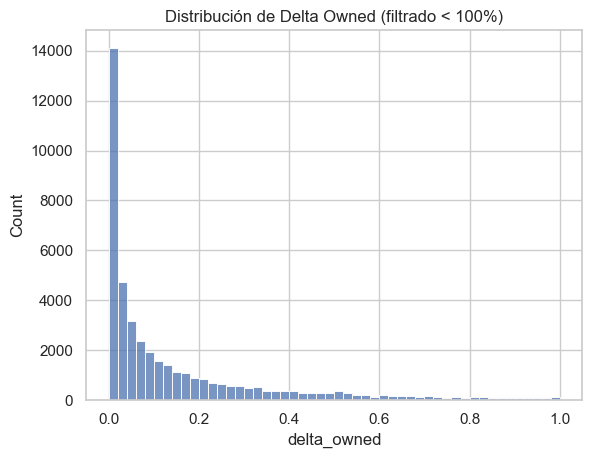

In [5]:
df['delta_owned'] = np.where(
    df['owned_after_cleaned'] != 0,
    df['qty_cleaned'] / df['owned_after_cleaned'],
    0
)

sns.histplot(df[df['delta_owned'] < 1]['delta_owned'], bins=50)
plt.title("Distribución de Delta Owned (filtrado < 100%)")

### 4.2 Reporting Lag
Días transcurridos entre el trade y la publicación.

Text(0.5, 1.0, 'Días de retraso en el reporte (Reporting Lag)')

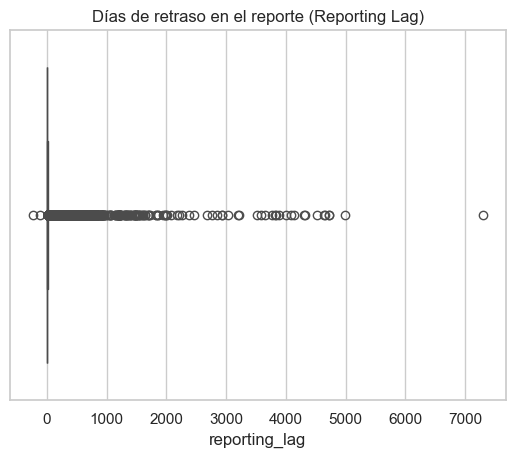

In [6]:
df['reporting_lag'] = (df['filing_date'] - df['trade_date']).dt.days

sns.boxplot(x=df['reporting_lag'])
plt.title("Días de retraso en el reporte (Reporting Lag)")

### 4.2.1 Análisis y Filtrado de Reporting Lag Extremo

**Problema detectado**: Algunas transacciones tienen `reporting_lag` de años (casos donde `trade_date` es muy antiguo pero `filing_date` es reciente).

Esto causa problemas porque:
- Aumenta innecesariamente el rango de fechas para descargar datos de Tiingo
- Probablemente son errores en los datos o correcciones tardías sin valor predictivo

**Solución**: Filtrar transacciones con `reporting_lag` > 180 días (6 meses)

Estadísticas de Reporting Lag:
count    45914.000000
mean        13.406564
std        126.712446
min       -243.000000
25%          1.000000
50%          2.000000
75%          4.000000
max       7309.000000
Name: reporting_lag, dtype: float64

Máximo reporting_lag: 7309 días
Transacciones con lag > 180 días: 647
Transacciones con lag > 365 días: 354

 Rango de trade_date ANTES del filtrado:
  Desde: 2004-05-09 00:00:00
  Hasta: 2026-02-02 00:00:00
  Total registros: 45914

 Después de filtrar (lag <= 180 días):
  Desde: 2017-10-10 00:00:00
  Hasta: 2026-02-02 00:00:00
  Total registros: 45267
  Registros eliminados: 647 (1.41%)


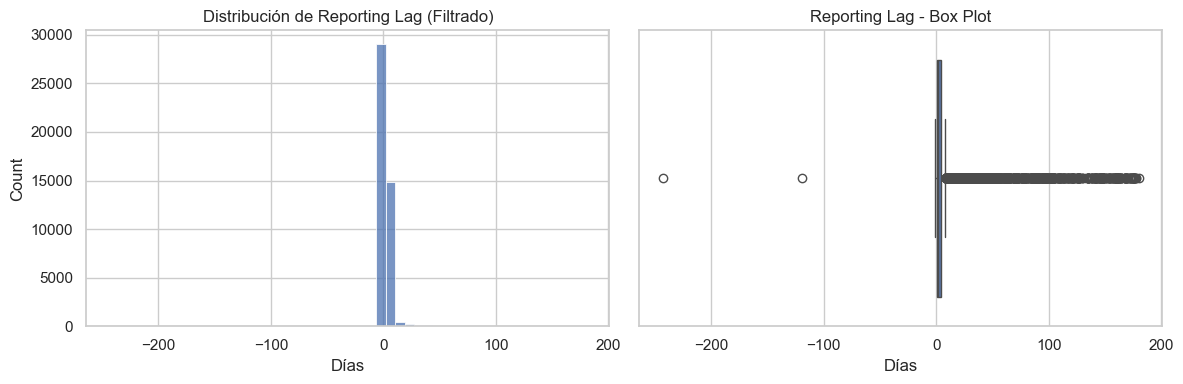

In [7]:
# Analizar distribución de reporting_lag
print("Estadísticas de Reporting Lag:")
print(df['reporting_lag'].describe())
print(f"\nMáximo reporting_lag: {df['reporting_lag'].max()} días")
print(f"Transacciones con lag > 180 días: {(df['reporting_lag'] > 180).sum()}")
print(f"Transacciones con lag > 365 días: {(df['reporting_lag'] > 365).sum()}")

# Analizar rango de fechas antes del filtrado
print(f"\n Rango de trade_date ANTES del filtrado:")
print(f"  Desde: {df['trade_date'].min()}")
print(f"  Hasta: {df['trade_date'].max()}")
print(f"  Total registros: {len(df)}")

# Filtrar casos extremos (reporting_lag > 180 días)
MAX_REPORTING_LAG = 180
df_filtered = df[df['reporting_lag'] <= MAX_REPORTING_LAG].copy()

print(f"\n Después de filtrar (lag <= {MAX_REPORTING_LAG} días):")
print(f"  Desde: {df_filtered['trade_date'].min()}")
print(f"  Hasta: {df_filtered['trade_date'].max()}")
print(f"  Total registros: {len(df_filtered)}")
print(f"  Registros eliminados: {len(df) - len(df_filtered)} ({100*(len(df) - len(df_filtered))/len(df):.2f}%)")

# Actualizar df con los datos filtrados
df = df_filtered

# Visualizar distribución después del filtrado
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['reporting_lag'], bins=50)
plt.title("Distribución de Reporting Lag (Filtrado)")
plt.xlabel("Días")

plt.subplot(1, 2, 2)
sns.boxplot(x=df['reporting_lag'])
plt.title("Reporting Lag - Box Plot")
plt.xlabel("Días")

plt.tight_layout()

### 4.3 Insider Roles
Agrupamos y visualizamos quién está comprando.

Proporción de C-Level: 16.72%


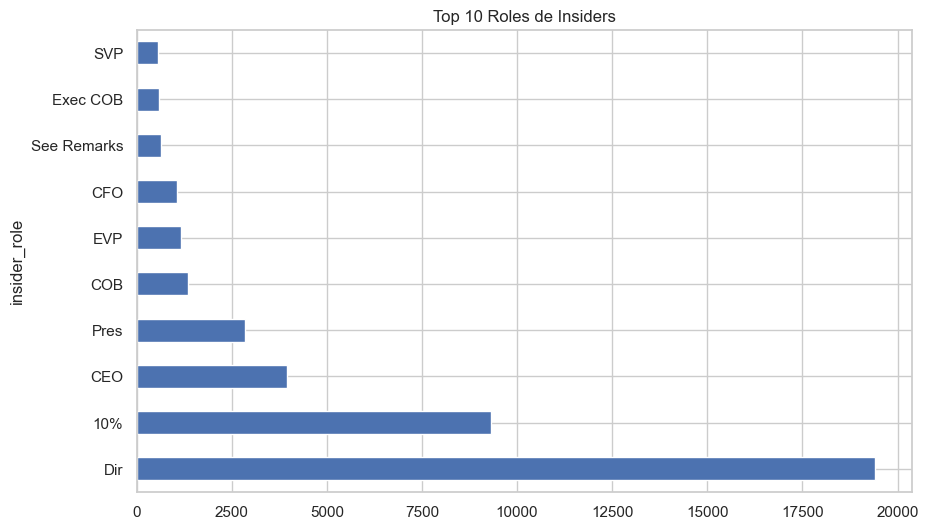

In [8]:
df['insider_role'] = df['Title'].str.split(',').str[0].str.strip()

# Identificar C-Level (CEO, CFO, etc.)
c_level_titles = ['CEO', 'CFO', 'COO', 'President', 'EVP', 'SVP']
df['is_c_level'] = df['insider_role'].apply(lambda x: any(title in str(x) for title in c_level_titles))

plt.figure(figsize=(10,6))
df['insider_role'].value_counts().nlargest(10).plot(kind='barh')
plt.title("Top 10 Roles de Insiders")
print(f"Proporción de C-Level: {df['is_c_level'].mean():.2%}")

### 4.5 Cluster Size - Compras Coordinadas (7 días)

**Insight clave**: Análisis mostró que **52.2% de transacciones ocurren en clusters** dentro de una ventana de 7 días.

**Feature**: `cluster_size` = Número de insiders **únicos** comprando la misma empresa en 7 días
- `1` = Compra individual (sin cluster)
- `2-5` = Cluster pequeño
- `6-20` = Cluster grande (**señal fuerte**)
- `20+` = Cluster masivo (**señal extrema**: CEO+CFO+EVP comprando juntos)

**Ejemplos reales**:
- FOMC (2023): `cluster_size = 66` → Señal masiva
- EBC (2020): `cluster_size = 25` → Muy fuerte

In [9]:
# Calcular cluster_size: Insiders únicos en ventana de 7 días (mismo ticker + misma semana)
df['week_year'] = df['trade_date'].dt.to_period('W')
df['ticker_week'] = df['ticker'] + '_' + df['week_year'].astype(str)

# Contar insiders únicos por ticker-semana
cluster_counts = df.groupby('ticker_week')['owner_name'].nunique()
df['cluster_size'] = df['ticker_week'].map(cluster_counts)

# Limpiar columnas temporales
df.drop(columns=['ticker_week', 'week_year'], inplace=True)

print("Feature cluster_size creado")
print(f"\n Distribución:")
print(f"   Individual (1): {(df['cluster_size'] == 1).sum():,} ({100*(df['cluster_size'] == 1).mean():.1f}%)")
print(f"   Cluster 2-5: {((df['cluster_size'] >= 2) & (df['cluster_size'] <= 5)).sum():,} ({100*((df['cluster_size'] >= 2) & (df['cluster_size'] <= 5)).mean():.1f}%)")
print(f"   Cluster 6-20: {((df['cluster_size'] >= 6) & (df['cluster_size'] <= 20)).sum():,} ({100*((df['cluster_size'] >= 6) & (df['cluster_size'] <= 20)).mean():.1f}%)")
print(f"   Cluster 20+: {(df['cluster_size'] > 20).sum():,} ({100*(df['cluster_size'] > 20).mean():.1f}%)")

print(f"\n Top 5 clusters más grandes:")
print(df.nlargest(5, 'cluster_size')[['ticker', 'trade_date', 'cluster_size', 'is_c_level']].to_string(index=False))

Feature cluster_size creado

 Distribución:
   Individual (1): 28,522 (63.0%)
   Cluster 2-5: 13,798 (30.5%)
   Cluster 6-20: 2,860 (6.3%)
   Cluster 20+: 46 (0.1%)

 Top 5 clusters más grandes:
ticker trade_date  cluster_size  is_c_level
   EBC 2020-10-14          24.0       False
   EBC 2020-10-14          24.0        True
   EBC 2020-10-14          24.0       False
   EBC 2020-10-14          24.0       False
   EBC 2020-10-14          24.0        True


Text(0.5, 0, 'Insiders por Evento')

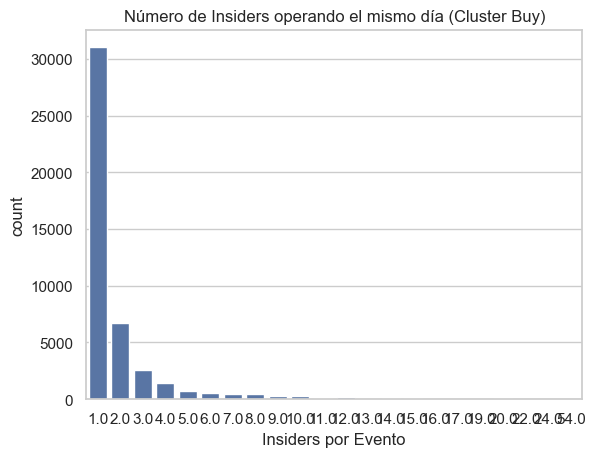

In [10]:
df['cluster_buy'] = df.groupby(['ticker', 'trade_date'])['ticker'].transform('count')

sns.countplot(x=df['cluster_buy'])
plt.title("Número de Insiders operando el mismo día (Cluster Buy)")
plt.xlabel("Insiders por Evento")

## 5. Exportar Datos Procesados

In [11]:
output_dir = project_root / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

columns_to_save = [
    'ticker', 'filing_date', 'trade_date', 'insider_role', 
    'transaction_value', 'delta_owned', 'owned_pct_change', 
    'reporting_lag', 'is_c_level', 
    'cluster_buy',
]

df[columns_to_save].to_parquet(output_dir / "insider_trades_processed.parquet", index=False)
print("Datos guardados con cluster_size!")
print(f"\n Features totales: {len(columns_to_save)}")
print(f"Filas: {len(df):,}")

Datos guardados con cluster_size!

 Features totales: 10
Filas: 45,267
